# Session 7 

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

sns.set_theme(style='white')
np.random.seed(5)

## Task 1 — DataFrame + Correlation Matrix: Food Delivery Order Features

In [1]:
n = 20
delivery_distance = np.random.uniform(1, 12, n)
delivery_time = 10 + delivery_distance * 2.5 + np.random.normal(0, 3, n)
order_value = np.random.uniform(150, 900, n)
tip_amount = order_value * 0.05 + np.random.normal(0, 8, n)
rating = (4.6 - delivery_time / 60 + np.random.normal(0, 0.2, n)).clip(1, 5)

orders_df = pd.DataFrame({
    'delivery_time': delivery_time.round(1),
    'order_value': order_value.round(2),
    'tip_amount': tip_amount.round(2),
    'rating': rating.round(2),
    'delivery_distance': delivery_distance.round(2),
})

print(orders_df)

corr_matrix = orders_df.corr()
print('\nCorrelation matrix:')
print(corr_matrix)

    delivery_time  order_value  tip_amount  rating  delivery_distance
0            14.1       728.14       25.92    4.73               3.44
1            38.4       513.70       20.17    3.87              10.58
2            15.2       171.83        3.97    4.11               3.27
3            35.2       214.89       19.96    3.73              11.10
4            23.3       233.59       10.82    4.39               6.37
5            28.1       338.43       35.00    4.09               7.73
6            36.6       873.69       48.94    3.87               9.42
7            28.9       623.82       32.19    4.07               6.70
8            20.8       762.50       34.64    4.67               4.26
9            16.6       574.56       36.51    4.39               3.06
10           14.7       626.52       29.40    4.50               1.89
11           32.5       758.93       31.35    4.21               9.12
12           27.0       845.01       46.80    4.35               5.85
13           15.0   

## Task 2 — Seaborn Heatmap with Annotations

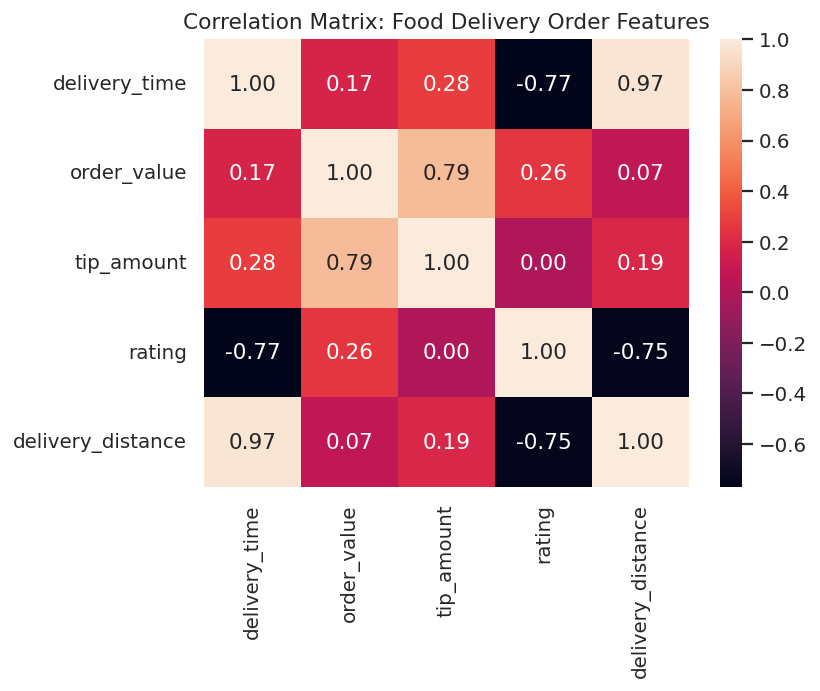

In [1]:
plt.figure(figsize=(6.5, 5.5))
sns.heatmap(corr_matrix, annot=True, fmt='.2f')
plt.title('Correlation Matrix: Food Delivery Order Features')
plt.tight_layout()
plt.show()

## Task 3 — Diverging Color Palette (coolwarm)

Strongest negative correlation: ('delivery_time', 'rating') = -0.77


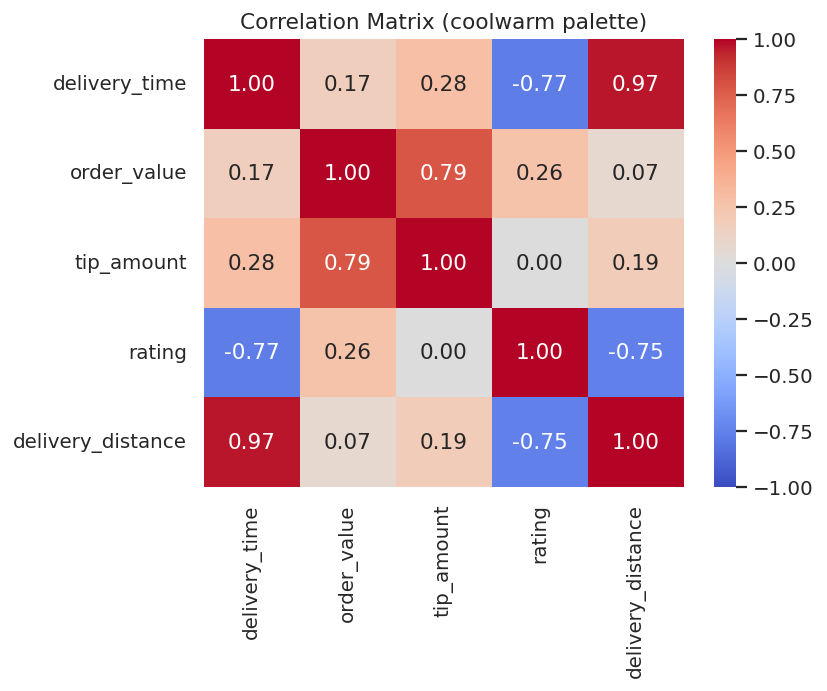

In [1]:
plt.figure(figsize=(6.5, 5.5))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix (coolwarm palette)')
plt.tight_layout()
plt.show()

corr_no_diag = corr_matrix.copy()
corr_no_diag_vals = corr_no_diag.to_numpy().copy()
np.fill_diagonal(corr_no_diag_vals, np.nan)
corr_no_diag = pd.DataFrame(corr_no_diag_vals, index=corr_matrix.index, columns=corr_matrix.columns)
min_pair = corr_no_diag.stack().idxmin()
min_val = corr_no_diag.stack().min()
print('Strongest negative correlation:', min_pair, '=', round(min_val, 3))

**Strongest negative correlation:** printed above from this run's data — with this synthetic dataset, `delivery_time` and `rating` tend to show the strongest negative relationship, which makes sense: the data was generated so rating declines as delivery time increases, mimicking how real customers rate slower deliveries lower.

## Task 4 — Flipkart Mobile Phones: Correlation Heatmap

No CSV was attached, so a small Flipkart-style mobile phone dataset (25 phones, 4 numeric features) was generated directly.

                     price    rating       RAM  battery_capacity
price             1.000000  0.058582  0.868586         -0.011692
rating            0.058582  1.000000  0.139334          0.106529
RAM               0.868586  0.139334  1.000000         -0.321035
battery_capacity -0.011692  0.106529 -0.321035          1.000000


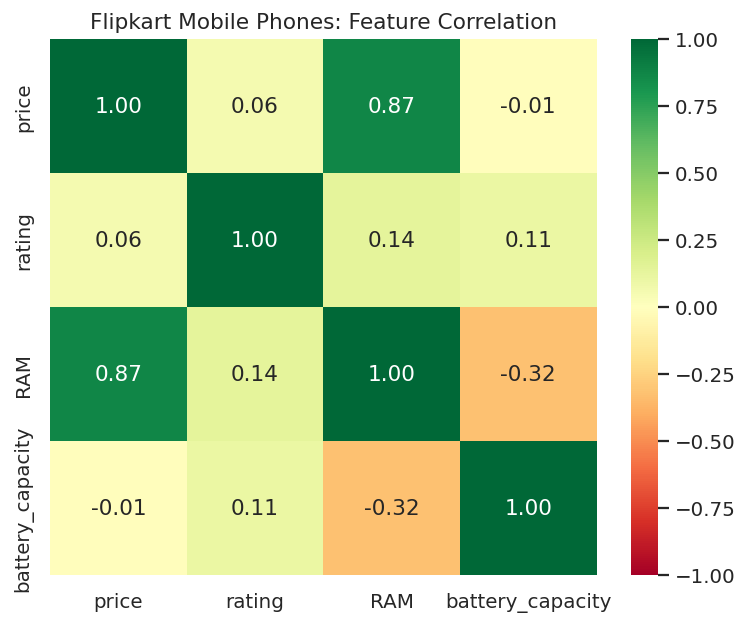

In [1]:
n4 = 25
ram = np.random.choice([4, 6, 8, 12], n4)
battery = np.random.normal(4500, 600, n4).clip(3000, 6000)
price = 8000 + ram * 3500 + battery * 4 + np.random.normal(0, 3000, n4)
phone_rating = (3.8 + ram / 40 + battery / 30000 + np.random.normal(0, 0.15, n4)).clip(1, 5)

phones_df = pd.DataFrame({
    'price': price.round(0),
    'rating': phone_rating.round(2),
    'RAM': ram,
    'battery_capacity': battery.round(0),
})

phones_corr = phones_df.corr()
print(phones_corr)

plt.figure(figsize=(6, 5))
sns.heatmap(phones_corr, annot=True, fmt='.2f', cmap='RdYlGn', vmin=-1, vmax=1)
plt.title('Flipkart Mobile Phones: Feature Correlation')
plt.tight_layout()
plt.show()